# Questão 1: EDA da tabela `orders`

**Premissas obrigatórias:**
- Utilizar apenas a tabela `orders`
- Não fazer limpeza nem tratamento dos dados
- Apenas observe, agregue e descreva


**Parte 1 - Visão geral da tabela `orders`**
- Quantidade total de linhas
- Quantidade total de colunas
- Intervalo de datas (`created_at`): mínima e máxima

In [19]:
from pathlib import Path

import pandas as pd

from src.db import get_engine
csv_path = Path('data/raw/orders.csv').resolve()
print('Lendo CSV de:', csv_path)

df = pd.read_csv(csv_path)
engine = get_engine()

print('Linhas:', len(df))
print('Colunas:', len(df.columns))
print('Data mínima (created_at):', df['created_at'].min())
print('Data máxima (created_at):', df['created_at'].max())

Lendo CSV de: C:\lh-nautical-desafio\data\raw\orders.csv
Linhas: 48998
Colunas: 13
Data mínima (created_at): 2020-01-01 01:19:28
Data máxima (created_at): 2026-12-31 23:43:09


**Parte 2 - Análise de valores numéricos (`total`)**
- Valor mínimo
- Valor máximo
- Valor médio

In [20]:
print("Mínimo:", df['total'].min())
print("Máximo:", df['total'].max())
print("Média:", round(df['total'].mean(), 2))

Mínimo: 32.62
Máximo: 127262.02
Média: 28704.99


**Parte 3 - Interpretação**

Diagnóstico sobre a confiabilidade da tabela `orders`:
- Possíveis outliers em `total`
- Qualidade dos dados (nulos/inconsistências)
- Pronta para análises ou exige tratamento prévio?


In [21]:
print("Nulos por coluna:\n", df.isnull().sum())
print("\nIDs duplicados:", df['id'].duplicated().sum())
print("\nDistribuição de status:\n", df['status'].value_counts())

print("\nNulos em salesperson_id por canal:")
print(pd.crosstab(df['channel'], df['salesperson_id'].isna(),
                  rownames=['channel'], colnames=['salesperson_id_nulo']))

datas_criacao = pd.to_datetime(df['created_at'])
data_referencia = pd.Timestamp.today().date()
qtd_datas_futuras = (datas_criacao.dt.date > data_referencia).sum()
divergencia_total = (df['subtotal'] - df['discount_amount'] - df['total']).abs()

print(f"\nData de referência da execução: {data_referencia}")
print("Registros com created_at posterior à data de referência:", qtd_datas_futuras)
print("Valores de total menores ou iguais a zero:", (df['total'] <= 0).sum())
print("Divergências acima de R$ 0,01 em subtotal - desconto = total:",
      (divergencia_total > 0.01).sum())
print("\nDescribe total:\n", df['total'].describe())

Nulos por coluna:
 id                     0
order_number           0
channel                0
customer_id            0
salesperson_id     24131
location_id            0
status                 0
subtotal               0
discount_amount        0
total                  0
placed_at              0
created_at             0
updated_at             0
dtype: int64

IDs duplicados: 0

Distribuição de status:
 status
paid         34365
confirmed     7335
cancelled     4847
draft         2451
Name: count, dtype: int64

Nulos em salesperson_id por canal:
salesperson_id_nulo  False  True 
channel                          
ecommerce            10211  24131
pos                  14656      0

Data de referência da execução: 2026-08-13
Registros com created_at posterior à data de referência: 4281
Valores de total menores ou iguais a zero: 0
Divergências acima de R$ 0,01 em subtotal - desconto = total: 0

Describe total:
 count     48998.000000
mean      28704.992077
std       19425.636818
min          32

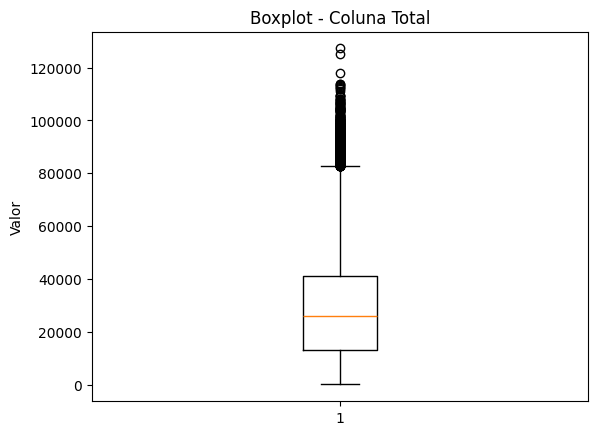

In [22]:
import matplotlib.pyplot as plt

plt.figure()
plt.boxplot(df['total'])
plt.title('Boxplot - Coluna Total')
plt.ylabel('Valor')
plt.show()

In [23]:
Q1 = df['total'].quantile(0.25)
Q3 = df['total'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

qtd_outliers = (df['total'] > limite_superior).sum()
print(f"Valores acima de {limite_superior:.2f} considerados outliers: {qtd_outliers}")

Valores acima de 82597.85 considerados outliers: 452


## Questão 1.1 - SQL

Query equivalente às métricas acima (ver `sql/queries/q1_eda_orders.sql`).


In [24]:
query = """
SELECT
    COUNT(*)             AS total_linhas,
    MIN(created_at)      AS data_minima,
    MAX(created_at)       AS data_maxima,
    MIN(total)            AS valor_minimo,
    MAX(total)            AS valor_maximo,
    ROUND(AVG(total), 2)  AS valor_medio
FROM orders;
"""
resultado = pd.read_sql(query, engine)
display(resultado)

diferenca_media = abs(float(resultado.loc[0, 'valor_medio']) - round(df['total'].mean(), 2))
print(f"Diferença entre as médias do CSV e do SQL: {diferenca_media:.2f}")
assert diferenca_media == 0, "CSV e SQL produziram médias diferentes"

,total_linhas,data_minima,data_maxima,valor_minimo,valor_maximo,valor_medio
0,48998,2020-01-01 01:19:28,2026-12-31 23:43:09,32.62,127262.02,28704.99


Diferença entre as médias do CSV e do SQL: 0.00


## Questão 1.2 - Validação

**Qual é o valor médio registrado na coluna `total`?**


R$ 28.704,99


## Questão 1.3 - Interpretação (relacionamento com demais tabelas)


A tabela `orders` possui 48.998 registros, IDs únicos e nenhum valor nulo em `total`. Todos os totais são positivos e a relação `subtotal - discount_amount = total` não apresenta divergências acima de um centavo. Esses sinais favorecem a confiabilidade estrutural da tabela.

Há, contudo, pontos que exigem definição de negócio antes de análises posteriores. Foram identificados 452 valores de `total` acima do limite superior de R$ 82.597,85 pelo critério do IQR. Eles podem influenciar a média, mas o tamanho elevado não prova que sejam erros e não justifica remoção automática. Também existem 24.131 valores nulos em `salesperson_id`, todos associados ao canal `ecommerce`. Esse padrão pode ser esperado para vendas sem vendedor, mas precisa ser confirmado com a área responsável.

O intervalo termina em 31/12/2026 e, na data em que o notebook foi executado, havia 4.281 registros futuros. Além disso, a tabela contém pedidos nos estados `cancelled` e `draft`. Esses registros são válidos na exploração bruta exigida pela Q1, mas as análises de negócio seguintes precisam definir explicitamente como tratar datas futuras e quais status representam vendas.

Portanto, a tabela é adequada para uma exploração inicial, mas ainda não deve ser usada de forma irrestrita em indicadores finais. Antes disso, é necessário validar as datas futuras, confirmar o significado dos vendedores nulos e estabelecer regras de status. Relacionamentos com clientes, itens e produtos também são necessários para contextualizar os valores extremos. Nenhum dado foi limpo ou alterado nesta análise.